# 03 — Validación contra la parametrización de Reyna 2006

## Por qué validar

Ya inspeccionamos los muones del run 1101 (50,000 showers de protón al OBSLEV del Fuego). Antes de usar esos muones para hacer un muograma, hay que estar seguros de que **la cascada está bien modelada**. Si CORSIKA estuviera dando una distribución de momentos sesgada o un ángulo cenital incorrecto, cualquier resultado de muografía iba a estar contaminado.

## Qué dice Reyna 2006

Reyna ([arXiv:hep-ph/0604145](https://arxiv.org/abs/hep-ph/0604145)) propuso un fit empírico de **todos los datos experimentales** del flujo de muones a nivel del mar (BESS, CAPRICE, L3+C, MARS, etc.) con una observación clave: el flujo a cualquier $\theta$ se obtiene del flujo vertical evaluado en el momento *vertical equivalente* $p_v = p \cos\theta$:

$$I(p, \theta) = \cos^3\theta \; I_v(p \cos\theta)$$

Esto no es accidente: refleja que los muones "inclinados" recorren más atmósfera (camino $\propto \sec\theta$), y la física de ese recorrido extra es lo que la fórmula encapsula. Si nuestra simulación no respeta ese escalamiento, *algo* está mal en cómo CORSIKA propaga los muones por la atmósfera.

## Dos tests clásicos

1. **Test 1 — shape vertical:** $dN/dp$ para muones casi-verticales ($\theta < 30^\circ$) debe seguir la misma forma que $I_v(p)$ de Reyna en todo el rango de momentos.
2. **Test 2 — escalamiento $\cos^3\theta$:** Si en varios bines de $\theta$ dividimos el flujo medido por $\cos^3\theta$ y graficamos vs $p\cos\theta$, todas las curvas deben **colapsar** sobre $I_v(p_v)$. Si no colapsan → la dependencia angular del MC está sesgada.

## Caveats antes de empezar

- **Altitud.** Reyna parametriza nivel del mar (~1030 g/cm²). Nuestro OBSLEV está a 2.5 km (~764 g/cm²). A baja energía ($\lesssim$ 5 GeV) esto causa un exceso real en MC respecto de Reyna porque los muones blandos sobreviven mejor a menor profundidad. **Esperamos diferencia, no es bug.**
- **Composición primaria.** Solo simulamos protones; los datos reales tienen ~10% de He y trazas pesadas. Estos modifican la normalización absoluta y el espectro a baja energía.
- **Normalización absoluta.** Para sacarla del MC habría que multiplicar por $\Phi_{primary}(>E_{min}) \cdot A_{sampling} \cdot T$. No lo hacemos aquí; **comparamos solo forma**, normalizando arbitrariamente.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis.corsika import CorsikaRun
from analysis.reyna import reyna_vertical_flux, reyna_flux

In [2]:
run = CorsikaRun(REPO_ROOT / 'sim' / 'output', run_number=6)
md = run.lst.metadata()
muons = run.particles.muons()

# Momento total |p| en GeV/c (Reyna usa momento, no energía cinética)
muons['p_gevc'] = np.sqrt(muons['px']**2 + muons['py']**2 + muons['pz']**2)
muons['theta_deg'] = np.degrees(muons['theta_rad'])
muons['p_vertical'] = muons['p_gevc'] * np.cos(muons['theta_rad'])

print(f'Run {md.run_number}: {len(muons)} muones, '
      f'OBSLEV={md.obslev_cm/1e5:.1f} km ({md.obslev_gcm2:.0f} g/cm²)')
print(f'Momento [GeV/c]: min={muons["p_gevc"].min():.2f}, '
      f'mediana={muons["p_gevc"].median():.2f}, max={muons["p_gevc"].max():.1f}')
print(f'Cenital [°]:    min={muons["theta_deg"].min():.1f}, '
      f'mediana={muons["theta_deg"].median():.1f}, max={muons["theta_deg"].max():.1f}')

/home/jarjarbinks/muon-tomography/.venv/lib/python3.13/site-packages/corsikaio/subblocks/run_header.py:84: UserWarning: Version unknown, using run header definition dtype of version 7.x
  warnings.warn("Version unknown, using run header definition dtype of version 7.x")
/home/jarjarbinks/muon-tomography/.venv/lib/python3.13/site-packages/corsikaio/subblocks/event_header.py:144: UserWarning: Version unknown, using event header dtype definition of version 7.7XXX
  warnings.warn("Version unknown, using event header dtype definition of version 7.7XXX")
/home/jarjarbinks/muon-tomography/.venv/lib/python3.13/site-packages/corsikaio/subblocks/event_end.py:46: UserWarning: Version unknown, using default event end definition dtype of version 7.x
  warnings.warn("Version unknown, using default event end definition dtype of version 7.x")


Run 14: 28926 muones, OBSLEV=2.0 km (813 g/cm²)
Momento [GeV/c]: min=0.05, mediana=2.22, max=405.5
Cenital [°]:    min=0.1, mediana=31.5, max=87.4


## Test 1 — Forma del espectro vertical

Seleccionamos muones con $\theta < 30^\circ$ (cuasi-verticales) y construimos el histograma normalizado $dN/dp$. Lo comparamos con $I_v(p)$ de Reyna **renormalizado arbitrariamente** para que coincida con MC en el bin de ~10 GeV/c (que tiene mejor estadística y está en el rango central de validez de Reyna).

**Qué buscar:** ambas curvas deben ser casi paralelas en log–log. Diferencias razonables ($\le$ 20–30%) en los extremos son esperables (efecto altitud, ECUTS, composición primaria). Curvaturas opuestas o desviaciones por factor 2× indican problema.

Muones cuasi-verticales (θ<30°): 13496


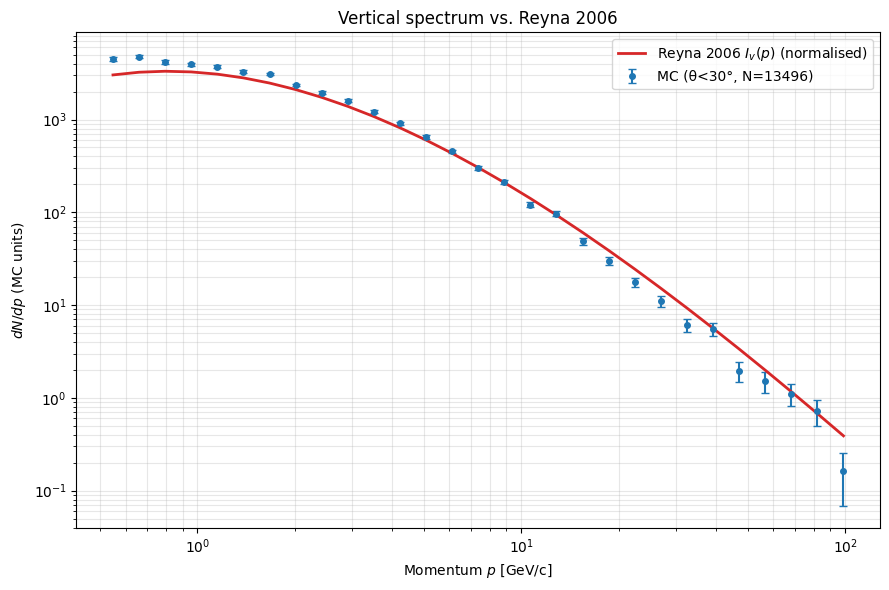

In [3]:
vertical = muons[muons['theta_deg'] < 30].copy()
print(f'Muones cuasi-verticales (θ<30°): {len(vertical)}')

# Binning logaritmico en momento
p_min, p_max = 0.5, vertical['p_gevc'].quantile(0.999)
bins = np.logspace(np.log10(p_min), np.log10(p_max), 30)
counts, edges = np.histogram(vertical['p_gevc'], bins=bins)
centers = np.sqrt(edges[:-1] * edges[1:])
widths = np.diff(edges)
mc_diff = counts / widths            # dN/dp en unidades MC arbitrarias
mc_err = np.sqrt(counts) / widths    # error Poisson

# Curva Reyna evaluada en los mismos puntos
reyna_v = reyna_vertical_flux(centers)

# Normalizar Reyna al MC en el bin con mejor estadística entre 5 y 20 GeV/c
mask_norm = (centers >= 5) & (centers <= 20) & (counts >= 30)
if mask_norm.any():
    norm = np.median(mc_diff[mask_norm] / reyna_v[mask_norm])
else:
    norm = mc_diff[counts.argmax()] / reyna_v[counts.argmax()]
reyna_scaled = reyna_v * norm

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(centers, mc_diff, yerr=mc_err, fmt='o', color='tab:blue',
            label=f'MC (θ<30°, N={len(vertical)})', capsize=3, ms=4)
ax.plot(centers, reyna_scaled, '-', color='tab:red', lw=2,
        label='Reyna 2006 $I_v(p)$ (normalised)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Momentum $p$ [GeV/c]')
ax.set_ylabel('$dN/dp$ (MC units)')
ax.set_title('Vertical spectrum vs. Reyna 2006')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
fig.savefig(REPO_ROOT / 'docs/paper/figures' / 'fig_reyna_vertical.png', bbox_inches='tight', dpi=300)
plt.show()

## Test 2 — Escalamiento $\cos^3\theta$

Si dividimos varios bines angulares por $\cos^3\theta$ y graficamos contra $p_v = p\cos\theta$, **todas** las curvas deben caer sobre la misma $I_v(p_v)$. Es el test más estricto: revisa que CORSIKA reproduce la dependencia angular completa, no solo la vertical.

**Qué buscar:** las curvas de distintos bines de $\theta$ deben quedar superpuestas dentro de barras Poisson. Si los bines de $\theta$ grande caen **arriba** o **abajo** de la curva vertical sistemáticamente → el modelo angular tiene sesgo.

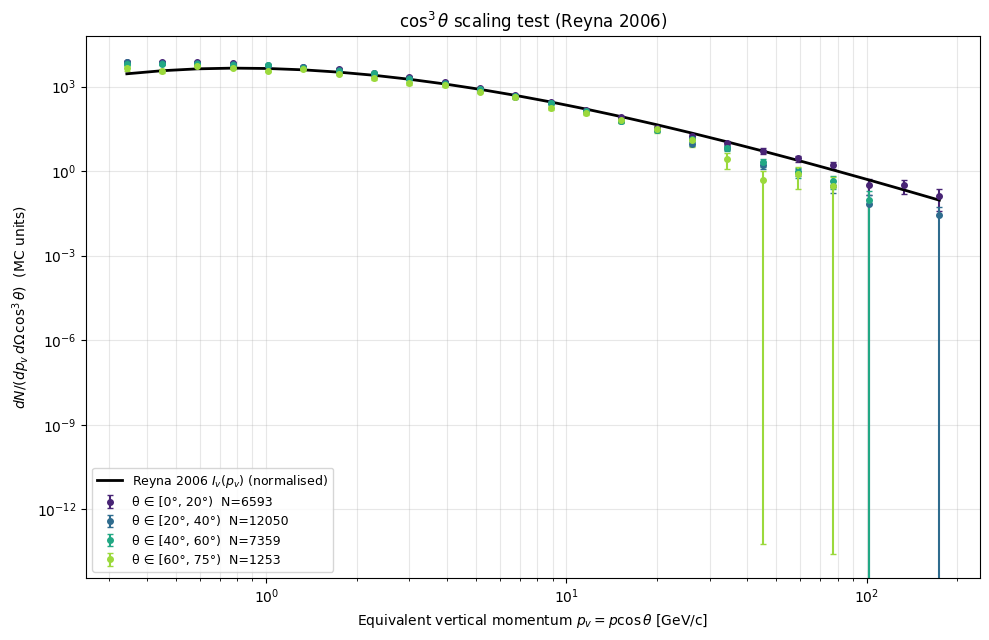

In [4]:
theta_bins = [(0, 20), (20, 40), (40, 60), (60, 75)]
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(theta_bins)))

# Binning comun en p_v (vertical equivalent)
pv_min, pv_max = 0.3, 200.0
pv_bins = np.logspace(np.log10(pv_min), np.log10(pv_max), 25)
pv_centers = np.sqrt(pv_bins[:-1] * pv_bins[1:])
pv_widths = np.diff(pv_bins)

# Para que las curvas colapsen correctamente, cada bin angular debe dividirse por
# (a) ancho del bin de momento, (b) angulo solido del bin angular ΔΩ = 2π(cosθ_lo-cosθ_hi),
# (c) cos^3(θ) de cada muon (mejor que cos^3 del promedio: usamos pesos por evento).
def per_event_flux(sel, pv_bins, theta_lo_deg, theta_hi_deg):
    if len(sel) < 50:
        return None, None, None
    p_v = (sel['p_gevc'] * np.cos(sel['theta_rad'])).to_numpy()
    w = 1.0 / np.cos(sel['theta_rad']).to_numpy()**3
    w_sum,  _ = np.histogram(p_v, bins=pv_bins, weights=w)
    w_sq,   _ = np.histogram(p_v, bins=pv_bins, weights=w**2)
    n_raw,  _ = np.histogram(p_v, bins=pv_bins)
    d_omega = 2*np.pi * (np.cos(np.radians(theta_lo_deg)) - np.cos(np.radians(theta_hi_deg)))
    diff = w_sum / np.diff(pv_bins) / d_omega
    err  = np.sqrt(w_sq) / np.diff(pv_bins) / d_omega
    return diff, err, n_raw

fig, ax = plt.subplots(figsize=(10, 6.5))
reyna_v_curve = reyna_vertical_flux(pv_centers)

# Calcular curvas para cada bin angular
curves = {}
for (lo, hi) in theta_bins:
    sel = muons[(muons['theta_deg'] >= lo) & (muons['theta_deg'] < hi)]
    curves[(lo, hi)] = per_event_flux(sel, pv_bins, lo, hi)

# Normalizacion global usando el bin (0,20) entre 3 y 30 GeV/c
ref_diff, _, ref_n = curves[(0, 20)]
mask = (pv_centers >= 3) & (pv_centers <= 30) & (ref_n >= 30)
global_norm = np.median(ref_diff[mask] / reyna_v_curve[mask]) if mask.any() else 1.0

for ((lo, hi), color) in zip(theta_bins, colors):
    diff, err, n_raw = curves[(lo, hi)]
    if diff is None: continue
    nz = n_raw > 0
    ax.errorbar(pv_centers[nz], diff[nz], yerr=err[nz], fmt='o', color=color,
                ms=4, capsize=2, label=f'θ ∈ [{lo}°, {hi}°)  N={int(n_raw.sum())}')

ax.plot(pv_centers, reyna_v_curve * global_norm, '-', color='black', lw=2,
        label='Reyna 2006 $I_v(p_v)$ (normalised)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Equivalent vertical momentum $p_v = p\\cos\\theta$ [GeV/c]')
ax.set_ylabel('$dN / (dp_v\\, d\\Omega\\, \\cos^3\\theta)$  (MC units)')
ax.set_title('$\\cos^3\\theta$ scaling test (Reyna 2006)')
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
fig.savefig(REPO_ROOT / 'docs/paper/figures' / 'fig_reyna_cos3.png', bbox_inches='tight', dpi=300)
plt.show()

## Diagnóstico cuantitativo — Ratio MC/Reyna por bin

El ojo puede engañar con escalas logarítmicas. Dividimos MC entre Reyna (ambos renormalizados al mismo punto) y graficamos el ratio: si la física es correcta, debe ser **plano ≈ 1** dentro de errores. Las desviaciones cuentan una historia:

| Síntoma | Posible causa física |
|---|---|
| Exceso MC a $p < 2$ GeV/c | Altitud (OBSLEV alto $\to$ menos absorción) o ECUTS muy bajo |
| Déficit MC a $p > 100$ GeV/c | Falta del componente de He/Fe (que aporta primarios más energéticos en promedio) |
| Pendiente diferente | Modelo hadrónico inadecuado (probar EPOS / QGSJET cambiando `HE_MODEL`) |
| Ratio depende de $\theta$ | Atmósfera plana (faltaría `CURVED`) o muestreo angular sesgado |

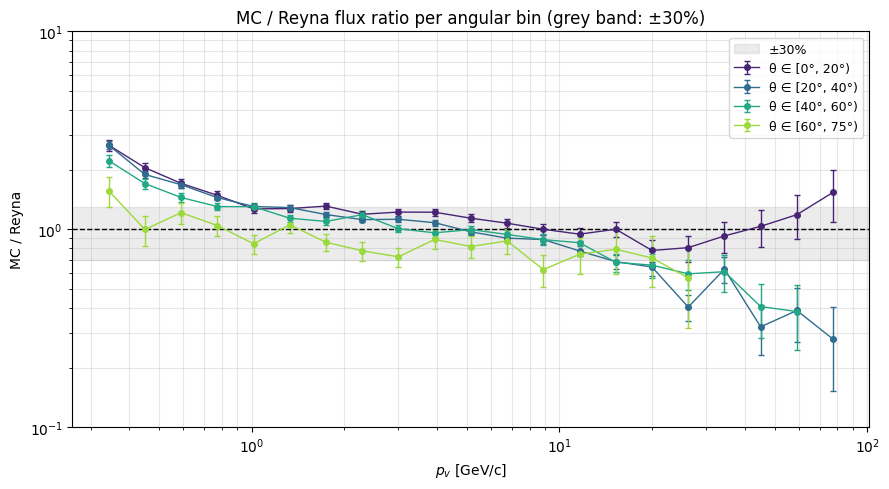


Ratio MC/Reyna mediana en 3–30 GeV/c (región más confiable):
  Ideal: ~1.0 (con desviaciones <30% por altitud/composición)
  θ ∈ [0°, 20°):  1.00   (N=6593)
  θ ∈ [20°, 40°):  0.89   (N=12050)
  θ ∈ [40°, 60°):  0.89   (N=7359)
  θ ∈ [60°, 75°):  0.75   (N=1253)


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ratios_summary = {}
for ((lo, hi), color) in zip(theta_bins, colors):
    diff, err, n_raw = curves[(lo, hi)]
    if diff is None: continue
    ratio = diff / (reyna_v_curve * global_norm)
    ratio_err = err / (reyna_v_curve * global_norm)
    nz = (n_raw >= 5)
    ax.errorbar(pv_centers[nz], ratio[nz], yerr=ratio_err[nz], fmt='o-', color=color,
                ms=4, capsize=2, lw=1, label=f'θ ∈ [{lo}°, {hi}°)')
    # Guardar mediana en region central 3-30 GeV/c
    mask = (pv_centers >= 3) & (pv_centers <= 30) & (n_raw >= 5)
    if mask.any():
        ratios_summary[(lo, hi)] = (np.median(ratio[mask]), int(n_raw.sum()))

ax.axhline(1.0, color='black', ls='--', lw=1)
ax.axhspan(0.7, 1.3, color='gray', alpha=0.15, label='±30%')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$p_v$ [GeV/c]')
ax.set_ylabel('MC / Reyna')
ax.set_title('MC / Reyna flux ratio per angular bin (grey band: ±30%)')
ax.set_ylim(0.1, 10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
fig.savefig(REPO_ROOT / 'docs/paper/figures' / 'fig_reyna_ratio.png', bbox_inches='tight', dpi=300)
plt.show()

print('\nRatio MC/Reyna mediana en 3–30 GeV/c (región más confiable):')
print('  Ideal: ~1.0 (con desviaciones <30% por altitud/composición)')
for (lo, hi), (r, n) in ratios_summary.items():
    flag = '' if 0.7 <= r <= 1.3 else '  ⚠️  fuera de ±30%'
    print(f'  θ ∈ [{lo}°, {hi}°):  {r:.2f}   (N={n}){flag}')

---

## Conclusión de la validación

Llená esta sección a mano después de correr el notebook (es donde se cierra el loop de validación para la tesis):

- [ ] Test 1 — shape vertical: ¿MC sigue la forma de Reyna en log–log? ¿Qué década de momento se desvía más?
- [ ] Test 2 — colapso $\cos^3\theta$: ¿los bines angulares se superponen? ¿Hay algún bin sistemáticamente arriba/abajo?
- [ ] Diagnóstico: ¿qué explica las desviaciones? (altitud, primario, modelo HE)

### Si los tests pasan razonablemente

Siguiente paso: **muograma sintético del Fuego** — aplicar corte geométrico (DEM) sobre el mapa angular del notebook 02 sección 6, ray-tracing por dentro del volcán y comparación con el muograma esperado *sin* volcán.

### Si no pasan

Antes del muograma hay que entender la discrepancia. Las palancas razonables, en orden de impacto:

1. **Composición primaria**: añadir He (≈9% del flujo) re-corriendo `make prod-corsika` con `PRMPAR 402` y combinando los DAT con pesos del espectro de Gaisser.
2. **Modelo HE**: probar `HE_MODEL=4` (SIBYLL 2.3e) que es el modelo más usado en códigos de astropartícula moderna.
3. **ECUTS**: subir el corte de muones de 10 MeV a 100 MeV si el exceso está en momento bajo (puede ser ruido numérico).